In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/Bird_Migration_Data_with_Origin.csv')
df

,Bird_ID,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,...,Migration_Interrupted,Interrupted_Reason,Tagged_By,Tag_Weight_g,Migration_Success,Recovery_Location_Known,Recovery_Time_days,Observation_Counts,Observation_Quality,Origin
0,B1000,Warbler,South America,Grassland,Stormy,Feeding,11.906566,-169.378251,30.377647,-21.366879,...,Yes,Storm,Researcher_A,27.0,Failed,No,102,56,Low,"11.906566441337574, -169.37825068830264"
1,B1001,Stork,North America,Grassland,Stormy,Breeding,62.301546,-111.475069,39.921092,47.963436,...,Yes,Injury,Researcher_C,14.2,Successful,Yes,118,61,Low,"62.301545854189925, -111.47506945435978"
2,B1002,Hawk,South America,Mountain,Stormy,Avoid Predators,87.861164,-78.727327,66.990980,19.448466,...,No,Lost Signal,Researcher_B,16.1,Failed,No,41,71,High,"87.86116387126651, -78.72732718179907"
3,B1003,Warbler,South America,Urban,Stormy,Climate Change,35.770590,153.104341,-49.003145,-157.868744,...,Yes,Lost Signal,Researcher_C,24.4,Successful,No,15,68,Low,"35.77058955392532, 153.1043405316318"
4,B1004,Crane,Europe,Urban,Windy,Avoid Predators,-21.611614,106.674824,11.681051,-115.022863,...,No,NaN,Researcher_B,25.8,Failed,Yes,73,67,Moderate,"-21.611614380025586, 106.67482429343966"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,B10995,Crane,Africa,Wetland,Windy,Climate Change,-80.397410,87.638661,74.628139,-1.283046,...,Yes,Predator,Researcher_C,20.6,Successful,No,99,59,Low,"-80.39740960510355, 87.6386606594711"
9996,B10996,Hawk,Europe,Forest,Windy,Avoid Predators,-47.192670,2.850794,20.149497,-77.025629,...,Yes,Predator,Researcher_B,7.8,Failed,No,117,82,Moderate,"-47.19267029278711, 2.8507940097474886"
9997,B10997,Goose,Europe,Wetland,Stormy,Avoid Predators,32.392299,-32.037925,28.625721,-13.844319,...,No,Lost Signal,Researcher_B,17.8,Failed,No,79,66,High,"32.39229860010022, -32.037925286267495"
9998,B10998,Crane,South America,Mountain,Stormy,Breeding,-41.145112,84.837740,74.612320,-74.675591,...,Yes,Lost Signal,Researcher_C,5.5,Successful,No,29,18,High,"-41.14511237593718, 84.83774044917067"


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 42 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Bird_ID                  10000 non-null  object 
 1   Species                  10000 non-null  object 
 2   Region                   10000 non-null  object 
 3   Habitat                  10000 non-null  object 
 4   Weather_Condition        10000 non-null  object 
 5   Migration_Reason         10000 non-null  object 
 6   Start_Latitude           10000 non-null  float64
 7   Start_Longitude          10000 non-null  float64
 8   End_Latitude             10000 non-null  float64
 9   End_Longitude            10000 non-null  float64
 10  Flight_Distance_km       10000 non-null  float64
 11  Flight_Duration_hours    10000 non-null  float64
 12  Average_Speed_kmph       10000 non-null  float64
 13  Max_Altitude_m           10000 non-null  int64  
 14  Min_Altitude_m         

In [6]:
df.describe()

,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,Flight_Distance_km,Flight_Duration_hours,Average_Speed_kmph,Max_Altitude_m,Min_Altitude_m,Temperature_C,...,Pressure_hPa,Visibility_km,Tag_Battery_Level_%,Signal_Strength_dB,Rest_Stops,Predator_Sightings,Flock_Size,Tag_Weight_g,Recovery_Time_days,Observation_Counts
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,-0.321812,-0.394588,0.084391,0.467617,2504.036134,49.994020,49.953394,5504.80830,500.111800,12.566930,...,1000.440810,10.636970,54.651800,-69.8408,7.380000,4.490200,248.714500,17.605870,60.490800,49.872800
std,51.919190,104.083440,51.709437,103.438134,499.723298,10.026108,5.085296,2595.28577,229.782907,13.073405,...,28.959614,5.504623,25.839271,9.9189,4.023583,2.872826,144.943771,7.200088,34.434028,28.601997
min,-89.999003,-179.993975,-89.998482,-179.902756,527.700000,12.600000,30.430000,1000.00000,100.000000,-10.000000,...,950.000000,1.000000,10.000000,-107.9000,1.000000,0.000000,1.000000,5.000000,1.000000,1.000000
25%,-45.390697,-91.444680,-43.664719,-88.871564,2169.632500,43.200000,46.530000,3277.75000,300.000000,1.200000,...,975.000000,5.900000,32.000000,-76.6000,4.000000,2.000000,124.000000,11.400000,31.000000,25.000000
50%,-0.138849,-0.479892,-0.163116,1.280823,2511.150000,50.050000,50.040000,5521.00000,501.000000,12.500000,...,1000.950000,10.700000,55.000000,-69.8000,7.000000,5.000000,248.000000,17.700000,61.000000,50.000000
75%,44.480926,89.640253,44.957102,91.196076,2841.452500,56.800000,53.360000,7740.25000,698.000000,24.000000,...,1025.500000,15.400000,77.000000,-63.1000,11.000000,7.000000,376.000000,24.000000,91.000000,74.000000
max,89.980302,179.989973,89.989145,179.955036,4428.320000,91.000000,68.950000,9999.00000,899.000000,35.000000,...,1050.000000,20.000000,99.000000,-33.3000,14.000000,9.000000,499.000000,30.000000,119.000000,99.000000


In [7]:
df.isnull().sum()

,0
Bird_ID,0
Species,0
Region,0
Habitat,0
Weather_Condition,0
Migration_Reason,0
Start_Latitude,0
Start_Longitude,0
End_Latitude,0
End_Longitude,0


In [8]:
df = df.fillna("NS") # Not specified
df.isnull().sum()

,0
Bird_ID,0
Species,0
Region,0
Habitat,0
Weather_Condition,0
Migration_Reason,0
Start_Latitude,0
Start_Longitude,0
End_Latitude,0
End_Longitude,0


In [9]:
df.columns

Index(['Bird_ID', 'Species', 'Region', 'Habitat', 'Weather_Condition',
       'Migration_Reason', 'Start_Latitude', 'Start_Longitude', 'End_Latitude',
       'End_Longitude', 'Flight_Distance_km', 'Flight_Duration_hours',
       'Average_Speed_kmph', 'Max_Altitude_m', 'Min_Altitude_m',
       'Temperature_C', 'Wind_Speed_kmph', 'Humidity_%', 'Pressure_hPa',
       'Visibility_km', 'Nesting_Success', 'Tag_Battery_Level_%',
       'Signal_Strength_dB', 'Migration_Start_Month', 'Migration_End_Month',
       'Rest_Stops', 'Predator_Sightings', 'Tag_Type', 'Migrated_in_Flock',
       'Flock_Size', 'Food_Supply_Level', 'Tracking_Quality',
       'Migration_Interrupted', 'Interrupted_Reason', 'Tagged_By',
       'Tag_Weight_g', 'Migration_Success', 'Recovery_Location_Known',
       'Recovery_Time_days', 'Observation_Counts', 'Observation_Quality',
       'Origin'],
      dtype='object')

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
# Feature Engineering
# creating a new column for speed
df['Speed (kmph)'] = df['Flight_Distance_km'] / df['Flight_Duration_hours']
df['Speed (kmph)'].describe()

,Speed (kmph)
count,10000.000000
mean,52.379806
std,16.124263
min,10.252868
25%,41.413355
50%,50.229689
75%,60.680402
max,181.598639


Text(0.5, 1.0, 'Speed Distribution of Birds')

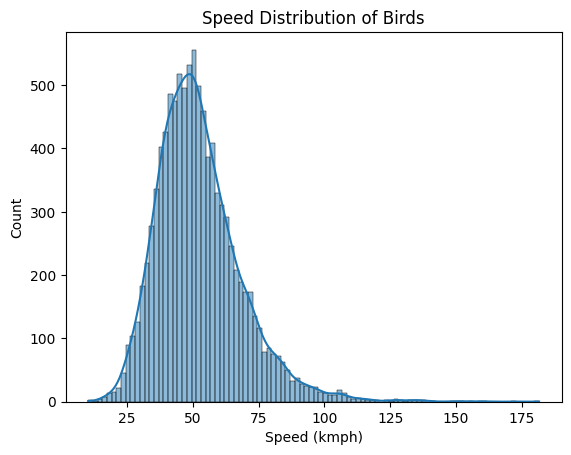

In [12]:
sns.histplot(df['Speed (kmph)'], kde = True)
plt.title('Speed Distribution of Birds')

In [13]:
# Outlier detection and removal
# outliers in speed by iqr method
Q1 = df['Speed (kmph)'].quantile(0.25)
Q3 = df['Speed (kmph)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Speed (kmph)'] < lower_bound) | (df['Speed (kmph)'] > upper_bound)]
outliers.shape

(264, 43)

In [14]:
# applying z-score method to find outliers
from scipy import stats
z_scores = np.abs(stats.zscore(df['Speed (kmph)']))
outliers_z = df[(z_scores > 3)]
outliers_z.shape

(118, 43)

In [15]:
# applying percentile method to find outliers
lower_percentile = df['Speed (kmph)'].quantile(0.01)
upper_percentile = df['Speed (kmph)'].quantile(0.99)
outliers_percentile = df[(df['Speed (kmph)'] < lower_percentile) | (df['Speed (kmph)'] > upper_percentile)]
outliers_percentile.shape

(200, 43)

In [16]:
df.drop(outliers.index, inplace=True)
df

,Bird_ID,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,...,Interrupted_Reason,Tagged_By,Tag_Weight_g,Migration_Success,Recovery_Location_Known,Recovery_Time_days,Observation_Counts,Observation_Quality,Origin,Speed (kmph)
0,B1000,Warbler,South America,Grassland,Stormy,Feeding,11.906566,-169.378251,30.377647,-21.366879,...,Storm,Researcher_A,27.0,Failed,No,102,56,Low,"11.906566441337574, -169.37825068830264",35.430101
1,B1001,Stork,North America,Grassland,Stormy,Breeding,62.301546,-111.475069,39.921092,47.963436,...,Injury,Researcher_C,14.2,Successful,Yes,118,61,Low,"62.301545854189925, -111.47506945435978",70.781996
3,B1003,Warbler,South America,Urban,Stormy,Climate Change,35.770590,153.104341,-49.003145,-157.868744,...,Lost Signal,Researcher_C,24.4,Successful,No,15,68,Low,"35.77058955392532, 153.1043405316318",39.478365
4,B1004,Crane,Europe,Urban,Windy,Avoid Predators,-21.611614,106.674824,11.681051,-115.022863,...,NS,Researcher_B,25.8,Failed,Yes,73,67,Moderate,"-21.611614380025586, 106.67482429343966",54.084007
5,B1005,Hawk,Europe,Grassland,Stormy,Climate Change,-15.871617,138.292231,18.594214,-175.116068,...,Lost Signal,Researcher_B,18.5,Failed,No,37,63,Moderate,"-15.8716165438901, 138.29223115055436",56.476749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,B10995,Crane,Africa,Wetland,Windy,Climate Change,-80.397410,87.638661,74.628139,-1.283046,...,Predator,Researcher_C,20.6,Successful,No,99,59,Low,"-80.39740960510355, 87.6386606594711",44.994084
9996,B10996,Hawk,Europe,Forest,Windy,Avoid Predators,-47.192670,2.850794,20.149497,-77.025629,...,Predator,Researcher_B,7.8,Failed,No,117,82,Moderate,"-47.19267029278711, 2.8507940097474886",47.962810
9997,B10997,Goose,Europe,Wetland,Stormy,Avoid Predators,32.392299,-32.037925,28.625721,-13.844319,...,Lost Signal,Researcher_B,17.8,Failed,No,79,66,High,"32.39229860010022, -32.037925286267495",52.245675
9998,B10998,Crane,South America,Mountain,Stormy,Breeding,-41.145112,84.837740,74.612320,-74.675591,...,Lost Signal,Researcher_C,5.5,Successful,No,29,18,High,"-41.14511237593718, 84.83774044917067",48.609124


In [17]:
df = df.drop(columns = ["Bird_ID"])
df

,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,Flight_Distance_km,...,Interrupted_Reason,Tagged_By,Tag_Weight_g,Migration_Success,Recovery_Location_Known,Recovery_Time_days,Observation_Counts,Observation_Quality,Origin,Speed (kmph)
0,Warbler,South America,Grassland,Stormy,Feeding,11.906566,-169.378251,30.377647,-21.366879,1753.79,...,Storm,Researcher_A,27.0,Failed,No,102,56,Low,"11.906566441337574, -169.37825068830264",35.430101
1,Stork,North America,Grassland,Stormy,Breeding,62.301546,-111.475069,39.921092,47.963436,3263.05,...,Injury,Researcher_C,14.2,Successful,Yes,118,61,Low,"62.301545854189925, -111.47506945435978",70.781996
3,Warbler,South America,Urban,Stormy,Climate Change,35.770590,153.104341,-49.003145,-157.868744,2317.38,...,Lost Signal,Researcher_C,24.4,Successful,No,15,68,Low,"35.77058955392532, 153.1043405316318",39.478365
4,Crane,Europe,Urban,Windy,Avoid Predators,-21.611614,106.674824,11.681051,-115.022863,3077.38,...,NS,Researcher_B,25.8,Failed,Yes,73,67,Moderate,"-21.611614380025586, 106.67482429343966",54.084007
5,Hawk,Europe,Grassland,Stormy,Climate Change,-15.871617,138.292231,18.594214,-175.116068,2987.62,...,Lost Signal,Researcher_B,18.5,Failed,No,37,63,Moderate,"-15.8716165438901, 138.29223115055436",56.476749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Crane,Africa,Wetland,Windy,Climate Change,-80.397410,87.638661,74.628139,-1.283046,2357.69,...,Predator,Researcher_C,20.6,Successful,No,99,59,Low,"-80.39740960510355, 87.6386606594711",44.994084
9996,Hawk,Europe,Forest,Windy,Avoid Predators,-47.192670,2.850794,20.149497,-77.025629,2901.75,...,Predator,Researcher_B,7.8,Failed,No,117,82,Moderate,"-47.19267029278711, 2.8507940097474886",47.962810
9997,Goose,Europe,Wetland,Stormy,Avoid Predators,32.392299,-32.037925,28.625721,-13.844319,3019.80,...,Lost Signal,Researcher_B,17.8,Failed,No,79,66,High,"32.39229860010022, -32.037925286267495",52.245675
9998,Crane,South America,Mountain,Stormy,Breeding,-41.145112,84.837740,74.612320,-74.675591,2663.78,...,Lost Signal,Researcher_C,5.5,Successful,No,29,18,High,"-41.14511237593718, 84.83774044917067",48.609124


In [18]:
# Specieswise Exploration
unique_species = df['Species'].nunique()
unique_species

7

In [19]:
species_counts = df['Species'].value_counts()
species_counts

,count
Species,
Hawk,1424
Stork,1403
Warbler,1390
Swallow,1389
Eagle,1388
Goose,1384
Crane,1358


In [20]:
df_Hawk = df[df['Species'] == 'Hawk']
df_Stork = df[df['Species'] == 'Stork']
df_warbler = df[df['Species'] == 'Warbler']
df_Swallow = df[df['Species'] == 'Swallow']
df_Eagle = df[df['Species'] == 'Eagle']
df_Goose = df[df['Species'] == 'Goose']
df_Crane = df[df['Species'] == 'Crane']

In [21]:
df_Hawk.describe()

,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,Flight_Distance_km,Flight_Duration_hours,Average_Speed_kmph,Max_Altitude_m,Min_Altitude_m,Temperature_C,...,Visibility_km,Tag_Battery_Level_%,Signal_Strength_dB,Rest_Stops,Predator_Sightings,Flock_Size,Tag_Weight_g,Recovery_Time_days,Observation_Counts,Speed (kmph)
count,1424.000000,1424.000000,1424.000000,1424.000000,1424.000000,1424.000000,1424.000000,1424.000000,1424.000000,1424.000000,...,1424.000000,1424.000000,1424.000000,1424.000000,1424.000000,1424.000000,1424.000000,1424.000000,1424.000000,1424.000000
mean,-1.754063,-1.672068,-1.622733,-4.591568,2499.778511,50.316152,49.867086,5569.910112,489.877107,12.629354,...,10.695646,54.333567,-69.773806,7.422753,4.498596,248.162921,17.510604,60.388343,49.447331,51.383321
std,51.376102,104.225961,51.430703,101.191623,491.031400,9.435271,5.147201,2562.345380,229.476075,13.132448,...,5.437950,25.945542,9.883025,3.963777,2.894733,143.681678,7.187827,34.294539,28.816404,13.649841
min,-89.766742,-179.993975,-89.998482,-179.307138,734.060000,21.300000,32.940000,1013.000000,100.000000,-10.000000,...,1.000000,10.000000,-103.500000,1.000000,0.000000,1.000000,5.000000,1.000000,1.000000,15.519239
25%,-47.540035,-94.439704,-44.405634,-91.812209,2186.232500,43.600000,46.437500,3433.000000,292.750000,1.200000,...,6.000000,32.000000,-76.400000,4.000000,2.000000,125.000000,11.400000,30.000000,24.000000,41.618014
50%,-0.713005,-1.760269,-1.624903,-5.146269,2504.430000,50.200000,49.970000,5628.000000,481.000000,12.700000,...,11.000000,55.000000,-69.400000,7.000000,5.000000,244.000000,17.350000,59.500000,49.000000,50.177933
75%,42.769671,90.522109,41.808797,84.221584,2816.505000,57.000000,53.435000,7784.250000,688.000000,24.100000,...,15.300000,76.000000,-63.000000,11.000000,7.000000,371.250000,23.800000,91.000000,74.250000,59.721941
max,89.776359,178.996954,89.949190,179.057309,4214.800000,87.200000,66.800000,9995.000000,899.000000,35.000000,...,20.000000,99.000000,-39.200000,14.000000,9.000000,499.000000,30.000000,119.000000,99.000000,89.417747


/tmp/ipython-input-985108202.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Speed (kmph)', y='Species', data=Birds, palette='viridis')


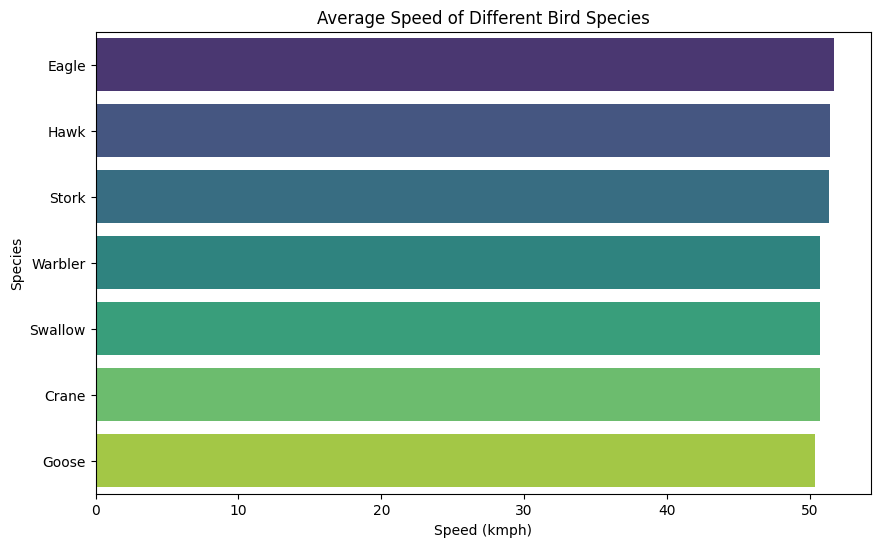

In [22]:
# speed distribution of Each Species
Birds = df.groupby('Species')['Speed (kmph)'].mean().reset_index()
Birds = Birds.sort_values(by='Speed (kmph)', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Speed (kmph)', y='Species', data=Birds, palette='viridis')
plt.title('Average Speed of Different Bird Species')
plt.xlabel('Speed (kmph)')
plt.ylabel('Species')
plt.show()

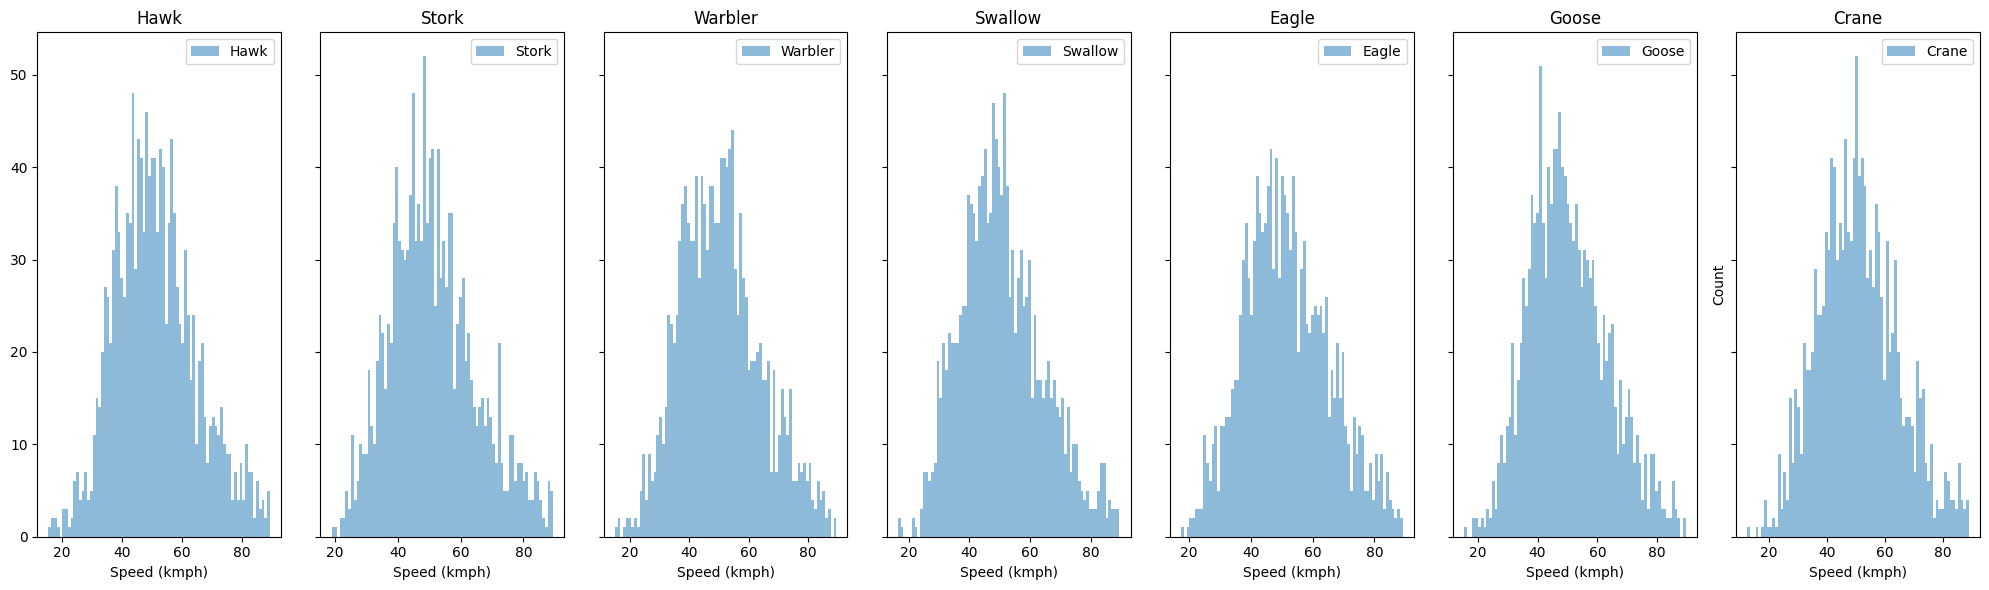

In [23]:
# Average speed of each species on histogram
Birds = [df_Hawk, df_Stork, df_warbler, df_Swallow, df_Eagle, df_Goose, df_Crane]
name = ['Hawk', 'Stork', 'Warbler', 'Swallow', 'Eagle', 'Goose', 'Crane']
fig, ax = plt.subplots(1, len(Birds), figsize=(20, 6), sharey=True)
for i, axis in enumerate(ax):
    axis.set_title(name[i])
    axis.set_xlabel('Speed (kmph)')
    axis.hist(Birds[i]['Speed (kmph)'], bins=80, alpha=0.5, label=name[i])
    axis.legend()
axis.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [24]:
df_Goose.describe()

,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,Flight_Distance_km,Flight_Duration_hours,Average_Speed_kmph,Max_Altitude_m,Min_Altitude_m,Temperature_C,...,Visibility_km,Tag_Battery_Level_%,Signal_Strength_dB,Rest_Stops,Predator_Sightings,Flock_Size,Tag_Weight_g,Recovery_Time_days,Observation_Counts,Speed (kmph)
count,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,...,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000
mean,1.894412,3.741226,-0.240647,3.792243,2480.700650,50.811994,49.967384,5473.523844,496.244220,12.035549,...,10.928251,54.859827,-70.020592,7.358382,4.528179,249.395954,17.508309,60.800578,50.070809,50.357343
std,51.984398,102.984974,51.907902,103.271618,498.141954,9.237647,5.157468,2635.622903,226.170048,13.133930,...,5.511111,25.684171,10.026341,3.996586,2.919367,143.454798,7.213722,34.219623,28.414796,13.237470
min,-89.875715,-179.344697,-89.777898,-179.685879,965.890000,24.900000,30.770000,1005.000000,100.000000,-10.000000,...,1.000000,10.000000,-99.000000,1.000000,0.000000,1.000000,5.000000,1.000000,1.000000,15.493557
25%,-43.004734,-83.946981,-43.364177,-85.844738,2130.480000,44.400000,46.552500,3239.250000,303.750000,0.500000,...,6.400000,33.000000,-76.825000,4.000000,2.000000,130.000000,11.375000,31.000000,25.000000,40.720391
50%,2.748311,3.253496,-0.909236,6.513428,2500.235000,51.000000,50.015000,5516.500000,494.500000,11.500000,...,11.200000,55.000000,-70.300000,7.000000,4.000000,249.500000,17.300000,62.000000,50.000000,48.821725
75%,47.061359,93.231076,45.771063,95.720837,2833.337500,57.100000,53.395000,7741.250000,685.000000,23.700000,...,15.800000,77.000000,-63.200000,11.000000,7.000000,375.250000,23.800000,90.250000,74.000000,58.755891
max,89.790797,179.942868,89.989145,179.955036,3883.160000,83.700000,65.210000,9998.000000,899.000000,35.000000,...,20.000000,99.000000,-37.700000,14.000000,9.000000,499.000000,30.000000,119.000000,99.000000,89.532219


In [25]:
# Checking by observation quality
df['Observation_Quality'].value_counts()

,count
Observation_Quality,
Low,3343
High,3261
Moderate,3132


In [26]:
# Do Certain species fly in larger flocks than others?
df['Flock_Size'].describe()

,Flock_Size
count,9736.000000
mean,248.384963
std,144.855615
min,1.000000
25%,124.000000
50%,247.000000
75%,375.000000
max,499.000000


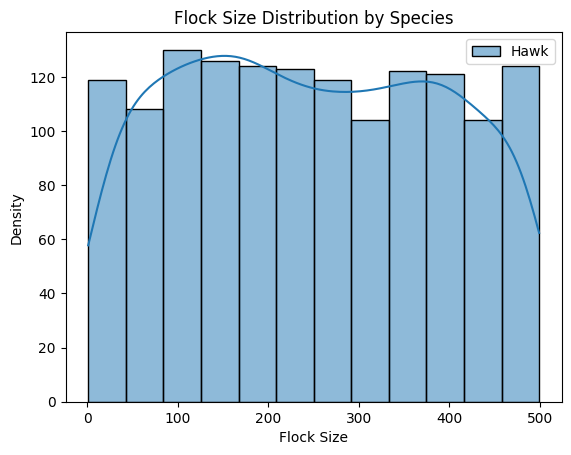

<Figure size 640x480 with 0 Axes>

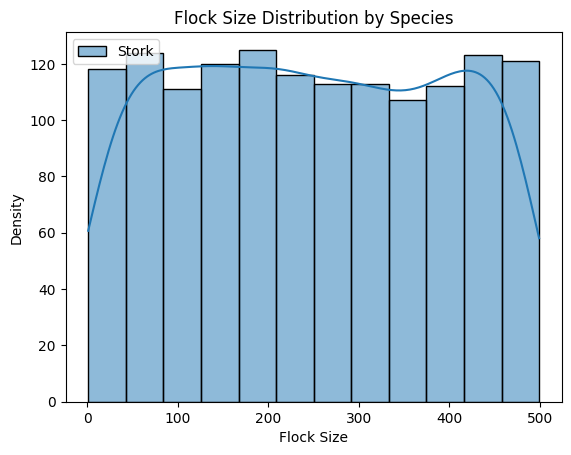

<Figure size 640x480 with 0 Axes>

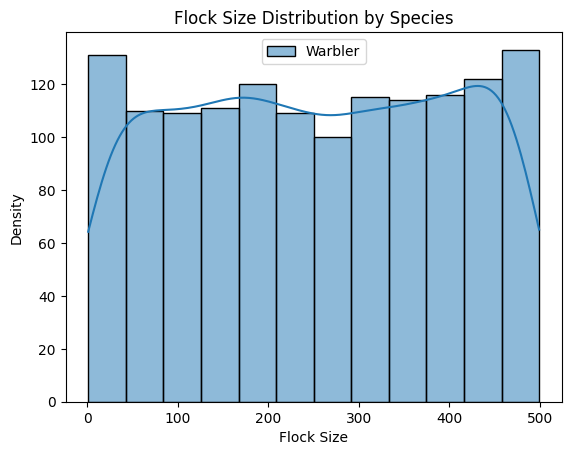

<Figure size 640x480 with 0 Axes>

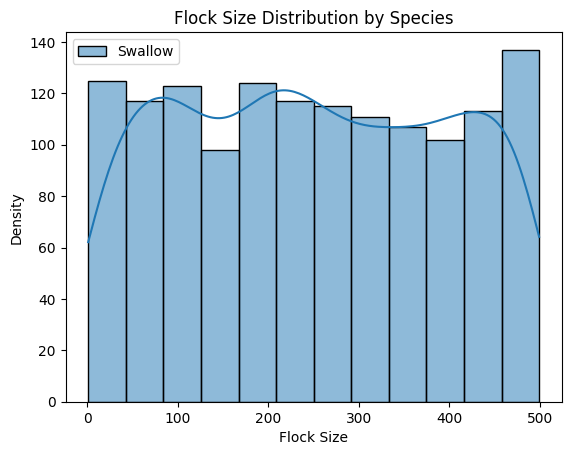

<Figure size 640x480 with 0 Axes>

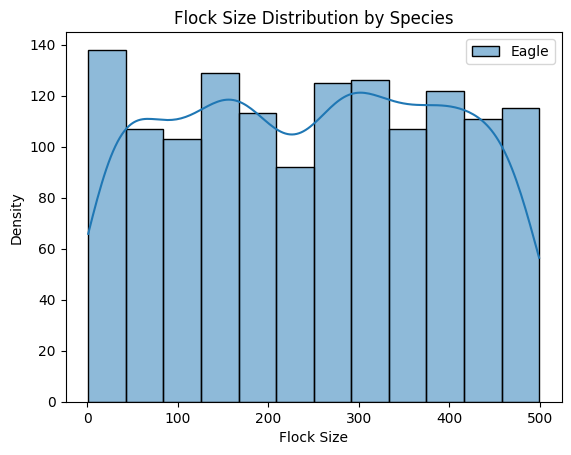

<Figure size 640x480 with 0 Axes>

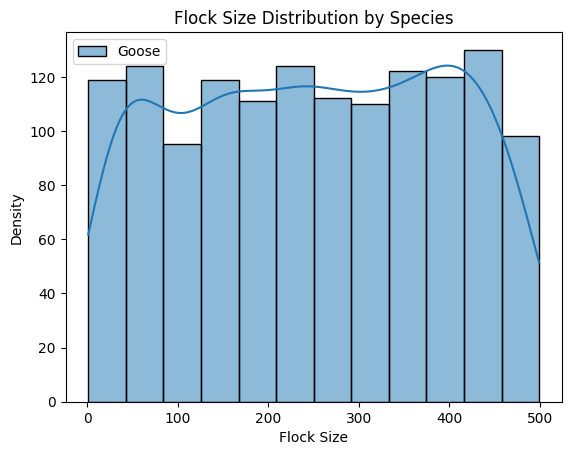

<Figure size 640x480 with 0 Axes>

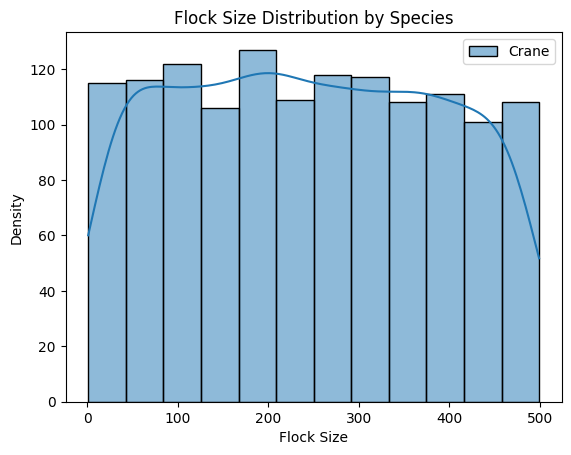

<Figure size 640x480 with 0 Axes>

In [28]:
Birds = [df_Hawk, df_Stork, df_warbler, df_Swallow, df_Eagle, df_Goose, df_Crane]
name = ['Hawk', 'Stork', 'Warbler', 'Swallow', 'Eagle', 'Goose', 'Crane']

for i, bird in enumerate(Birds):
    plt.subplots()
    sns.histplot(bird['Flock_Size'], kde = True, label=name[i])
    plt.legend()
    plt.title('Flock Size Distribution by Species')
    plt.xlabel('Flock Size')
    plt.ylabel('Density')
    plt.figure()
    plt.show()

In [29]:
# Specieswise migration success rate
Birds_migration_rate = pd.DataFrame(columns=['Species', 'Success Rate', 'Failed Rate'])
for i in range (len(Birds)):
    success_rate = Birds[i]['Migration_Success'].value_counts(normalize=True)[1]
    new_row = pd.DataFrame({'Species': [name[i]], 'Success Rate': [success_rate], "Failed Rate": [1 - success_rate]})
    Birds_migration_rate = pd.concat([Birds_migration_rate, new_row], ignore_index=True)
Birds_migration_rate

/tmp/ipython-input-1662695272.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  success_rate = Birds[i]['Migration_Success'].value_counts(normalize=True)[1]
/tmp/ipython-input-1662695272.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Birds_migration_rate = pd.concat([Birds_migration_rate, new_row], ignore_index=True)
/tmp/ipython-input-1662695272.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value b

,Species,Success Rate,Failed Rate
0,Hawk,0.496489,0.503511
1,Stork,0.491803,0.508197
2,Warbler,0.471223,0.528777
3,Swallow,0.475162,0.524838
4,Eagle,0.492795,0.507205
5,Goose,0.494220,0.505780
6,Crane,0.498527,0.501473


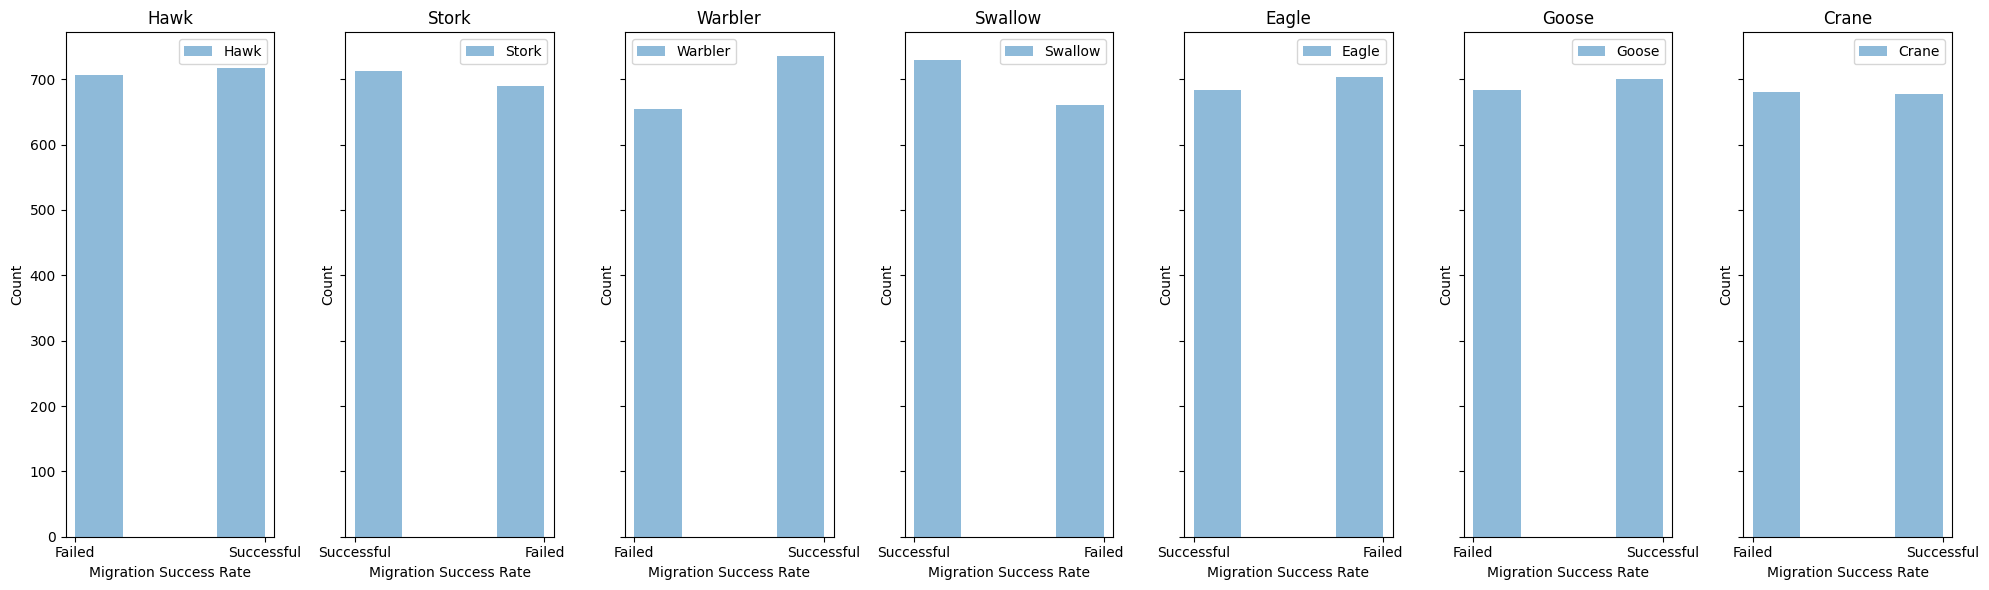

In [30]:
# Plotting Specieswise migration success and failure counts
Birds = [df_Hawk, df_Stork, df_warbler, df_Swallow, df_Eagle, df_Goose, df_Crane]
name = ['Hawk', 'Stork', 'Warbler', 'Swallow', 'Eagle', 'Goose', 'Crane']
fig, ax = plt.subplots(1, len(Birds), figsize=(20, 6), sharey=True)
for i, axis in enumerate(ax):
    axis.set_title(name[i])
    axis.set_xlabel('Migration Success Rate')
    axis.hist(Birds[i]['Migration_Success'], bins=4, alpha=0.5, label=name[i])
    axis.legend()
    axis.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [31]:
df[["Average_Speed_kmph", "Speed (kmph)"]]

,Average_Speed_kmph,Speed (kmph)
0,47.82,35.430101
1,48.41,70.781996
3,55.38,39.478365
4,53.92,54.084007
5,52.39,56.476749
...,...,...
9995,57.77,44.994084
9996,52.59,47.962810
9997,44.25,52.245675
9998,55.33,48.609124


In [32]:
df["Average_Speed_kmph"].describe()

,Average_Speed_kmph
count,9736.000000
mean,49.946143
std,5.080750
min,30.430000
25%,46.530000
50%,50.030000
75%,53.352500
max,68.950000


Weather impact on nesting success

In [33]:
# Using crosstab to count occurrences of Nesting Success for each Weather Condition
result = pd.crosstab(df['Weather_Condition'], df['Nesting_Success'])
result

Nesting_Success,No,Yes
Weather_Condition,,
Clear,922,949
Foggy,1059,1018
Rainy,971,904
Stormy,1008,947
Windy,954,1004


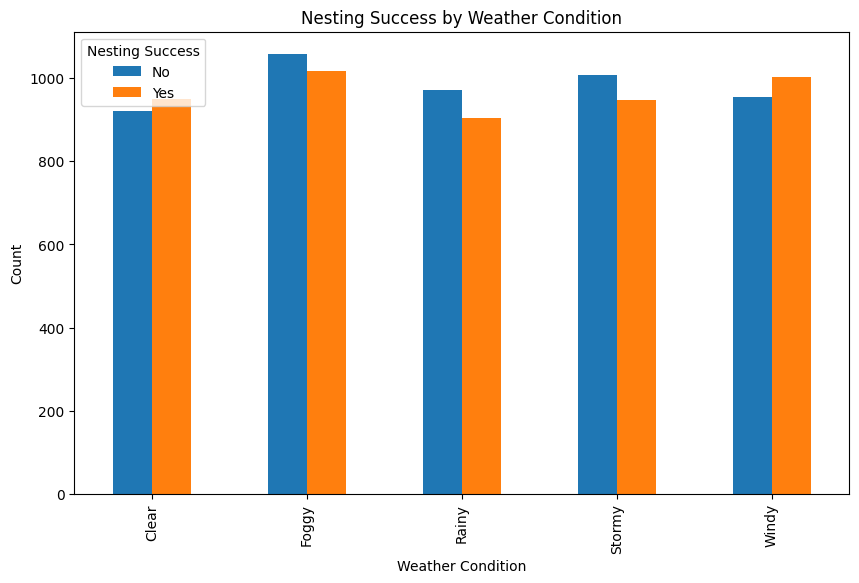

In [34]:
result.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Nesting Success by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Count')
plt.legend(title='Nesting Success')
plt.show()

In [35]:
# what conditons are interrupting migration
df['Migration_Interrupted'].value_counts()

,count
Migration_Interrupted,
Yes,4911
No,4825


In [36]:
df['Interrupted_Reason'].value_counts()

,count
Interrupted_Reason,
Storm,2007
Injury,1969
Predator,1948
NS,1927
Lost Signal,1885


In [37]:
crosstab_result = pd.crosstab(df['Migration_Interrupted'], df['Interrupted_Reason'])
crosstab_result

Interrupted_Reason,Injury,Lost Signal,NS,Predator,Storm
Migration_Interrupted,,,,,
No,985,956,950,967,967
Yes,984,929,977,981,1040


In [39]:
crosstab_result_new = pd.crosstab(df['Interrupted_Reason'], df['Migration_Interrupted'])
crosstab_result_new

Migration_Interrupted,No,Yes
Interrupted_Reason,,
Injury,985,984
Lost Signal,956,929
NS,950,977
Predator,967,981
Storm,967,1040


<Axes: xlabel='Interrupted_Reason'>

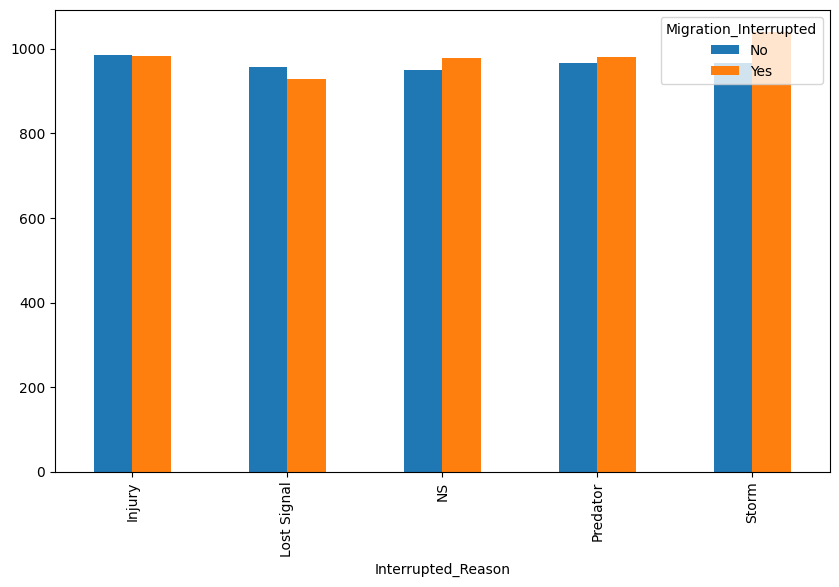

In [40]:
crosstab_result_new.plot(kind='bar', stacked=False, figsize=(10, 6))

In [41]:
# weather condition impact on migration
crosstab_weather = pd.crosstab(df['Weather_Condition'], df['Migration_Interrupted'])
crosstab_weather

Migration_Interrupted,No,Yes
Weather_Condition,,
Clear,927,944
Foggy,1029,1048
Rainy,937,938
Stormy,963,992
Windy,969,989


<Axes: xlabel='Weather_Condition'>

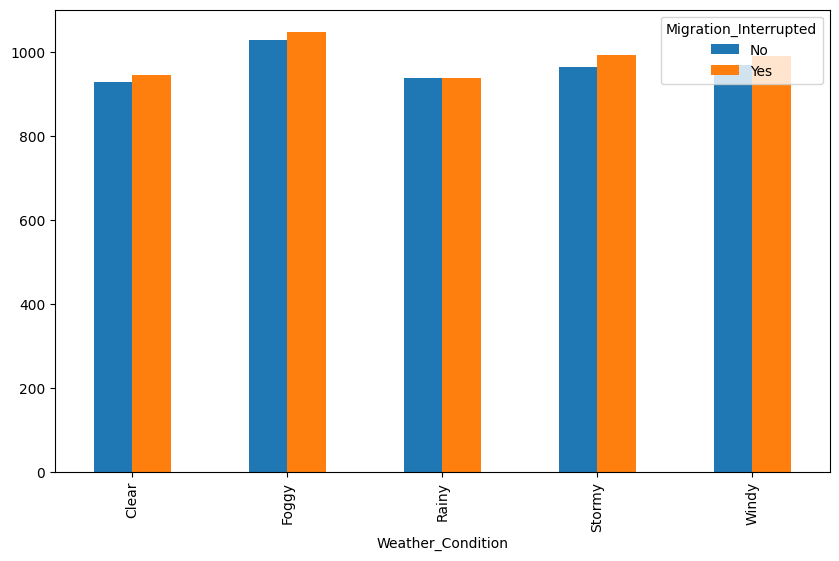

In [42]:
crosstab_weather.plot(kind='bar', stacked=False, figsize=(10, 6))

<Axes: xlabel='Weather_Condition'>

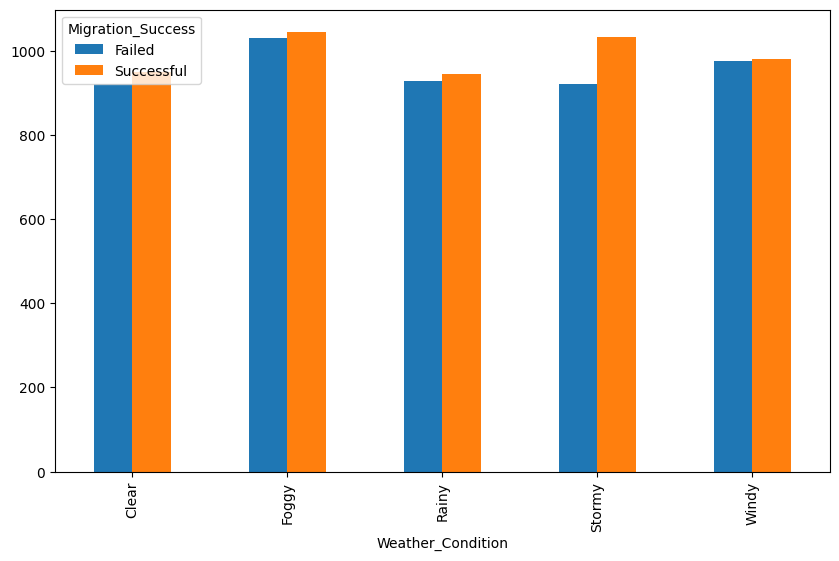

In [43]:
pd.crosstab(df['Weather_Condition'], df['Migration_Success']).plot(kind='bar', stacked=False, figsize=(10, 6))

In [45]:
# after being clear weather what interrupted migration
pd.crosstab(df['Weather_Condition'], df['Interrupted_Reason'])

Interrupted_Reason,Injury,Lost Signal,NS,Predator,Storm
Weather_Condition,,,,,
Clear,361,357,378,375,400
Foggy,420,397,394,430,436
Rainy,400,338,379,358,400
Stormy,401,387,396,407,364
Windy,387,406,380,378,407


In [46]:
df.groupby(df['Weather_Condition'] == 'Clear')['Interrupted_Reason'].value_counts()

Weather_Condition  Interrupted_Reason
False              Injury                1608
                   Storm                 1607
                   Predator              1573
                   NS                    1549
                   Lost Signal           1528
True               Storm                  400
                   NS                     378
                   Predator               375
                   Injury                 361
                   Lost Signal            357
Name: count, dtype: int64

In [47]:
clear = df[df['Weather_Condition'] == 'Clear'].groupby('Interrupted_Reason').value_counts()
clear

Interrupted_Reason  Species  Region         Habitat    Weather_Condition  Migration_Reason  Start_Latitude  Start_Longitude  End_Latitude  End_Longitude  Flight_Distance_km  Flight_Duration_hours  Average_Speed_kmph  Max_Altitude_m  Min_Altitude_m  Temperature_C  Wind_Speed_kmph  Humidity_%  Pressure_hPa  Visibility_km  Nesting_Success  Tag_Battery_Level_%  Signal_Strength_dB  Migration_Start_Month  Migration_End_Month  Rest_Stops  Predator_Sightings  Tag_Type   Migrated_in_Flock  Flock_Size  Food_Supply_Level  Tracking_Quality  Migration_Interrupted  Tagged_By     Tag_Weight_g  Migration_Success  Recovery_Location_Known  Recovery_Time_days  Observation_Counts  Observation_Quality  Origin                                    Speed (kmph)
Injury              Crane    Africa         Coastal    Clear              Breeding           65.346569      -117.669564       87.426476    -78.248321     2033.49             44.9                   49.84               2182            488             -3.2           57.2             82          1045.7        17.7           Yes              19                   -72.5               Sep                    Dec                  7           8                   GPS        Yes                49          Medium             Excellent         Yes                    Researcher_C  25.2          Successful         No                       16                  93                  High                 65.34656878396518, -117.66956430928708    45.289310       1
                                            Forest     Clear              Avoid Predators    74.299278       142.198772       72.185076     173.565760    1690.70             46.0                   62.42               2408            604             -5.6           30.4             52          1043.4        8.8            No               30                   -70.4               Jan                    Dec                  4           3                   Satellite  Yes                273         High               Good              No                     Researcher_A  21.0          Successful         No                       111                 97                  High                 74.29927822627866, 142.19877203799774     36.754348       1
                                                                          Feeding            83.591026      -17.708553       -85.359193     90.255381     1636.36             49.8                   59.84               2750            880              10.2          28.2             13          987.8         19.3           Yes              93                   -93.8               Nov                    Nov                  4           0                   GPS        Yes                414         Medium             Poor              No                     Researcher_C  27.8          Failed             Yes                      23                  71                  Low                  83.59102590107065, -17.708552746761995    32.858635       1
                                            Grassland  Clear              Climate Change     1.454539       -98.898483       -7.094659     -165.568122    1897.40             56.2                   49.78               6423            702              29.2          5.9              68          1011.1        8.5            Yes              19                   -71.5               Sep                    Mar                  13          0                   Radio      No                 64          Medium             Good              Yes                    Researcher_C  16.3          Failed             Yes                      118                 68                  High                 1.4545393602442829, -98.89848336910572    33.761566       1
                                                                          Feeding           -76.087253      -27.453737        40.768386     166.621451    2417.81             55.0                   46.21               4638            895              

In [48]:
foggy = df[df['Weather_Condition'] == 'Foggy'].groupby('Interrupted_Reason').value_counts()
foggy

Interrupted_Reason  Species  Region         Habitat   Weather_Condition  Migration_Reason  Start_Latitude  Start_Longitude  End_Latitude  End_Longitude  Flight_Distance_km  Flight_Duration_hours  Average_Speed_kmph  Max_Altitude_m  Min_Altitude_m  Temperature_C  Wind_Speed_kmph  Humidity_%  Pressure_hPa  Visibility_km  Nesting_Success  Tag_Battery_Level_%  Signal_Strength_dB  Migration_Start_Month  Migration_End_Month  Rest_Stops  Predator_Sightings  Tag_Type   Migrated_in_Flock  Flock_Size  Food_Supply_Level  Tracking_Quality  Migration_Interrupted  Tagged_By     Tag_Weight_g  Migration_Success  Recovery_Location_Known  Recovery_Time_days  Observation_Counts  Observation_Quality  Origin                                   Speed (kmph)
Injury              Crane    Africa         Coastal   Foggy              Avoid Predators    33.787665      -0.010265         75.659698     35.475563     2214.15             28.3                   48.32               2091            616              12.7          29.0             58          1043.7        16.5           No               53                   -85.8               Nov                    Mar                  11          5                   GPS        No                 109         High               Poor              No                     Researcher_C  6.0           Successful         Yes                      96                  26                  Low                  33.787665487698405, -0.0102649690661849  78.238516       1
                                                                         Climate Change     20.775407      -49.362828        45.818224     163.711593    3668.26             66.2                   50.77               6770            412              28.0          24.3             23          961.3         3.4            No               94                   -68.5               May                    Jun                  13          0                   Satellite  No                 23          Medium             Excellent         No                     Researcher_C  8.8           Failed             No                       90                  19                  Moderate             20.775407473435425, -49.362827637789394  55.411782       1
                                            Forest    Foggy              Climate Change    -81.298277      -65.855629        71.267511    -143.972790    2765.26             52.5                   48.64               2996            286              22.5          47.0             18          993.3         12.2           No               64                   -77.6               May                    Jun                  6           1                   Radio      No                 123         High               Fair              No                     Researcher_B  9.3           Successful         Yes                      57                  62                  High                 -81.29827684114973, -65.85562896535002   52.671619       1
                                                                                            66.967773      -84.600898       -72.391149     74.778785     2189.50             51.0                   45.71               2873            564             -3.9           45.7             98          1021.5        1.8            No               75                   -64.2               Apr                    Dec                  12          7                   Satellite  No                 276         Medium             Fair              Yes                    Researcher_C  16.2          Successful         Yes                      12                  53                  Low                  66.96777273758892, -84.6008981218233     42.931373       1
                                                                         Feeding           -51.317191      -110.996332       16.219175    -36.644523     2649.78             51.1                   51.63               4604            630              17.8       

In [52]:
df.Region.unique()

array(['South America', 'North America', 'Europe', 'Africa', 'Asia',
       'Australia'], dtype=object)

In [53]:
df.Habitat.unique()

array(['Grassland', 'Urban', 'Coastal', 'Wetland', 'Forest', 'Mountain'],
      dtype=object)

In [54]:
# habitatwise species distribution
df['Habitat'].value_counts()

,count
Habitat,
Wetland,1649
Coastal,1643
Urban,1629
Forest,1621
Mountain,1603
Grassland,1591


In [55]:
df["Region"].value_counts()

,count
Region,
South America,1660
North America,1656
Asia,1641
Africa,1623
Australia,1591
Europe,1565


In [56]:
Habitat_crosstab = pd.crosstab(df['Species'], df['Habitat'])
Habitat_crosstab

Habitat,Coastal,Forest,Grassland,Mountain,Urban,Wetland
Species,,,,,,
Crane,228,231,249,229,200,221
Eagle,254,224,226,219,211,254
Goose,238,232,228,240,213,233
Hawk,224,237,237,223,257,246
Stork,227,255,223,230,243,225
Swallow,243,223,204,234,243,242
Warbler,229,219,224,228,262,228


<Axes: xlabel='Species'>

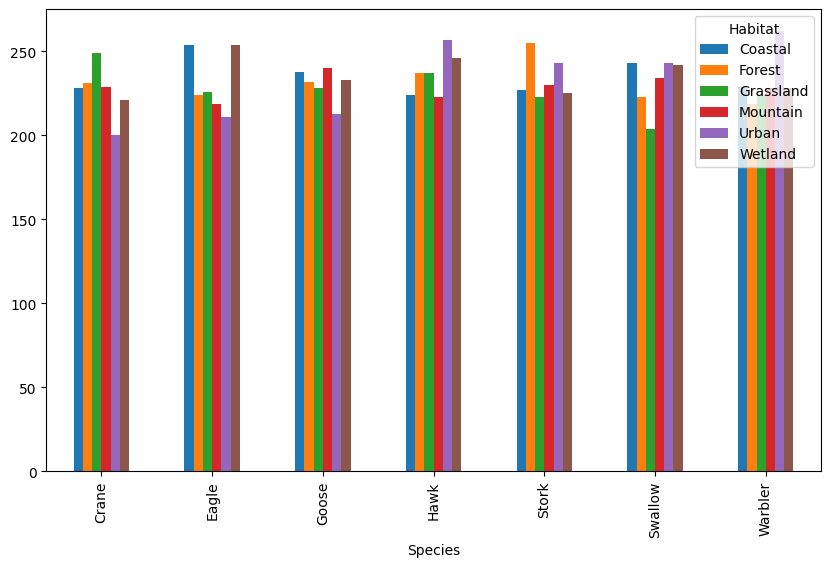

In [57]:
Habitat_crosstab.plot(kind='bar', stacked=False, figsize=(10, 6))

In [58]:
species_crosstab = pd.crosstab(df['Habitat'], df['Species'])
species_crosstab

Species,Crane,Eagle,Goose,Hawk,Stork,Swallow,Warbler
Habitat,,,,,,,
Coastal,228,254,238,224,227,243,229
Forest,231,224,232,237,255,223,219
Grassland,249,226,228,237,223,204,224
Mountain,229,219,240,223,230,234,228
Urban,200,211,213,257,243,243,262
Wetland,221,254,233,246,225,242,228


<Axes: xlabel='Habitat'>

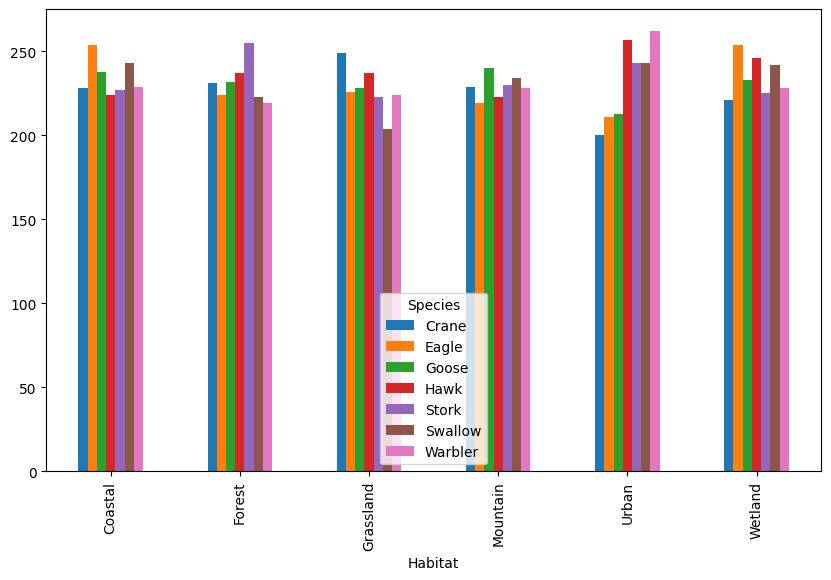

In [59]:
species_crosstab.plot(kind='bar', stacked=False, figsize=(10, 6))

In [60]:
# reducing the number of columns in the dataset based on their correlation with the target variable
# and removing the columns that are not significantly correlated with the target variable.
# This can help to reduce the dimensionality of the dataset and improve the performance of the model.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Migration_Success'] = le.fit_transform(df['Migration_Success'])

correlation_with_target = df.corr(numeric_only=True).loc[:, 'Migration_Success']
correlation_with_target.abs().sort_values(ascending=False)

,Migration_Success
Migration_Success,1.000000
Rest_Stops,0.028253
Min_Altitude_m,0.019555
Tag_Battery_Level_%,0.018219
Start_Longitude,0.017115
Flight_Distance_km,0.015938
Max_Altitude_m,0.013714
Speed (kmph),0.013063
End_Longitude,0.012273
Humidity_%,0.009439


In [61]:
objects = df.select_dtypes(include=['object']).columns
objects

Index(['Species', 'Region', 'Habitat', 'Weather_Condition', 'Migration_Reason',
       'Nesting_Success', 'Migration_Start_Month', 'Migration_End_Month',
       'Tag_Type', 'Migrated_in_Flock', 'Food_Supply_Level',
       'Tracking_Quality', 'Migration_Interrupted', 'Interrupted_Reason',
       'Tagged_By', 'Recovery_Location_Known', 'Observation_Quality',
       'Origin'],
      dtype='object')

In [62]:
df = df.drop(columns = ["Tagged_By"])
df

,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,Flight_Distance_km,...,Migration_Interrupted,Interrupted_Reason,Tag_Weight_g,Migration_Success,Recovery_Location_Known,Recovery_Time_days,Observation_Counts,Observation_Quality,Origin,Speed (kmph)
0,Warbler,South America,Grassland,Stormy,Feeding,11.906566,-169.378251,30.377647,-21.366879,1753.79,...,Yes,Storm,27.0,0,No,102,56,Low,"11.906566441337574, -169.37825068830264",35.430101
1,Stork,North America,Grassland,Stormy,Breeding,62.301546,-111.475069,39.921092,47.963436,3263.05,...,Yes,Injury,14.2,1,Yes,118,61,Low,"62.301545854189925, -111.47506945435978",70.781996
3,Warbler,South America,Urban,Stormy,Climate Change,35.770590,153.104341,-49.003145,-157.868744,2317.38,...,Yes,Lost Signal,24.4,1,No,15,68,Low,"35.77058955392532, 153.1043405316318",39.478365
4,Crane,Europe,Urban,Windy,Avoid Predators,-21.611614,106.674824,11.681051,-115.022863,3077.38,...,No,NS,25.8,0,Yes,73,67,Moderate,"-21.611614380025586, 106.67482429343966",54.084007
5,Hawk,Europe,Grassland,Stormy,Climate Change,-15.871617,138.292231,18.594214,-175.116068,2987.62,...,No,Lost Signal,18.5,0,No,37,63,Moderate,"-15.8716165438901, 138.29223115055436",56.476749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Crane,Africa,Wetland,Windy,Climate Change,-80.397410,87.638661,74.628139,-1.283046,2357.69,...,Yes,Predator,20.6,1,No,99,59,Low,"-80.39740960510355, 87.6386606594711",44.994084
9996,Hawk,Europe,Forest,Windy,Avoid Predators,-47.192670,2.850794,20.149497,-77.025629,2901.75,...,Yes,Predator,7.8,0,No,117,82,Moderate,"-47.19267029278711, 2.8507940097474886",47.962810
9997,Goose,Europe,Wetland,Stormy,Avoid Predators,32.392299,-32.037925,28.625721,-13.844319,3019.80,...,No,Lost Signal,17.8,0,No,79,66,High,"32.39229860010022, -32.037925286267495",52.245675
9998,Crane,South America,Mountain,Stormy,Breeding,-41.145112,84.837740,74.612320,-74.675591,2663.78,...,Yes,Lost Signal,5.5,1,No,29,18,High,"-41.14511237593718, 84.83774044917067",48.609124


In [63]:
df[['Migration_Start_Month', 'Migration_End_Month',  'Flight_Distance_km', 'Flight_Duration_hours', 'Average_Speed_kmph', 'Rest_Stops']]

,Migration_Start_Month,Migration_End_Month,Flight_Distance_km,Flight_Duration_hours,Average_Speed_kmph,Rest_Stops
0,Jan,Apr,1753.79,49.5,47.82,3
1,Apr,Dec,3263.05,46.1,48.41,2
3,Jan,Nov,2317.38,58.7,55.38,8
4,Oct,Oct,3077.38,56.9,53.92,11
5,Nov,May,2987.62,52.9,52.39,5
...,...,...,...,...,...,...
9995,Feb,Nov,2357.69,52.4,57.77,9
9996,Sep,Jun,2901.75,60.5,52.59,12
9997,Nov,Apr,3019.80,57.8,44.25,10
9998,Jan,May,2663.78,54.8,55.33,1


In [64]:
pd.crosstab(df['Migration_Start_Month'], df["Migration_End_Month"])

Migration_End_Month,Apr,Dec,Jun,Mar,May,Nov,Oct
Migration_Start_Month,,,,,,,
Apr,174,176,152,177,178,174,151
Feb,165,184,166,189,181,162,174
Jan,182,175,193,158,168,192,174
Mar,172,186,199,182,158,162,204
May,174,170,171,161,170,198,168
Nov,201,167,154,200,176,173,163
Oct,183,183,164,179,168,184,155
Sep,177,153,173,167,160,176,160


In [65]:
df = df.drop(columns = ["Tag_Weight_g"])
df

,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,Flight_Distance_km,...,Tracking_Quality,Migration_Interrupted,Interrupted_Reason,Migration_Success,Recovery_Location_Known,Recovery_Time_days,Observation_Counts,Observation_Quality,Origin,Speed (kmph)
0,Warbler,South America,Grassland,Stormy,Feeding,11.906566,-169.378251,30.377647,-21.366879,1753.79,...,Excellent,Yes,Storm,0,No,102,56,Low,"11.906566441337574, -169.37825068830264",35.430101
1,Stork,North America,Grassland,Stormy,Breeding,62.301546,-111.475069,39.921092,47.963436,3263.05,...,Good,Yes,Injury,1,Yes,118,61,Low,"62.301545854189925, -111.47506945435978",70.781996
3,Warbler,South America,Urban,Stormy,Climate Change,35.770590,153.104341,-49.003145,-157.868744,2317.38,...,Good,Yes,Lost Signal,1,No,15,68,Low,"35.77058955392532, 153.1043405316318",39.478365
4,Crane,Europe,Urban,Windy,Avoid Predators,-21.611614,106.674824,11.681051,-115.022863,3077.38,...,Good,No,NS,0,Yes,73,67,Moderate,"-21.611614380025586, 106.67482429343966",54.084007
5,Hawk,Europe,Grassland,Stormy,Climate Change,-15.871617,138.292231,18.594214,-175.116068,2987.62,...,Good,No,Lost Signal,0,No,37,63,Moderate,"-15.8716165438901, 138.29223115055436",56.476749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Crane,Africa,Wetland,Windy,Climate Change,-80.397410,87.638661,74.628139,-1.283046,2357.69,...,Good,Yes,Predator,1,No,99,59,Low,"-80.39740960510355, 87.6386606594711",44.994084
9996,Hawk,Europe,Forest,Windy,Avoid Predators,-47.192670,2.850794,20.149497,-77.025629,2901.75,...,Poor,Yes,Predator,0,No,117,82,Moderate,"-47.19267029278711, 2.8507940097474886",47.962810
9997,Goose,Europe,Wetland,Stormy,Avoid Predators,32.392299,-32.037925,28.625721,-13.844319,3019.80,...,Excellent,No,Lost Signal,0,No,79,66,High,"32.39229860010022, -32.037925286267495",52.245675
9998,Crane,South America,Mountain,Stormy,Breeding,-41.145112,84.837740,74.612320,-74.675591,2663.78,...,Poor,Yes,Lost Signal,1,No,29,18,High,"-41.14511237593718, 84.83774044917067",48.609124


In [66]:
df['Displacement'] = ((df['End_Latitude'] - df['Start_Latitude'])**2 + (df['End_Longitude'] - df['Start_Longitude'])**2)**0.5

In [67]:
df["Displacement"].describe()

,Displacement
count,9736.000000
mean,144.340339
std,77.817917
min,1.781920
25%,83.578634
50%,134.970770
75%,196.276826
max,380.087588


<Axes: xlabel='Displacement', ylabel='Count'>

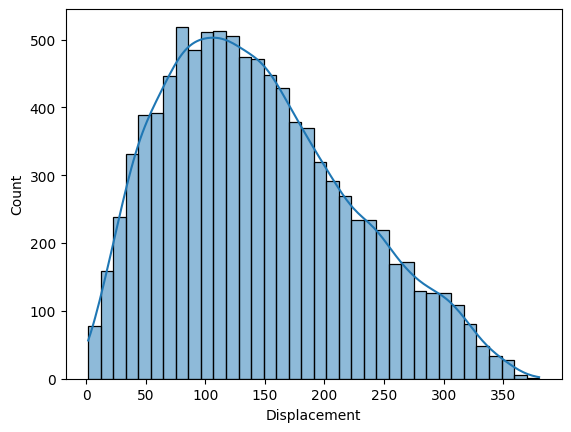

In [68]:
sns.histplot(df['Displacement'], kde = True)

<Axes: xlabel='Flight_Distance_km', ylabel='Count'>

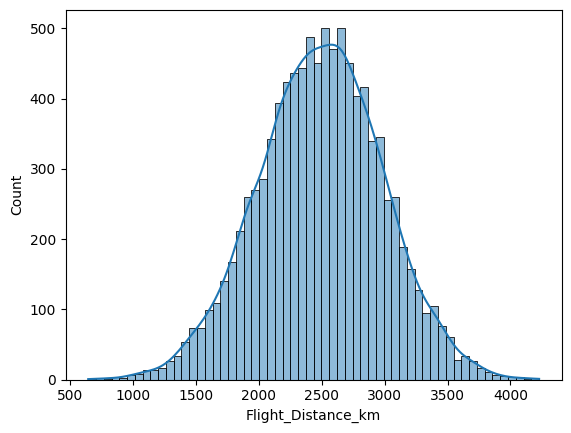

In [69]:
sns.histplot(df['Flight_Distance_km'], kde = True)

In [70]:
df["Flight_Distance_km"].describe()

,Flight_Distance_km
count,9736.000000
mean,2490.147402
std,492.447095
min,643.330000
25%,2159.712500
50%,2498.785000
75%,2825.612500
max,4227.820000


In [71]:
Flight_Crosstab = pd.crosstab(df['Flight_Distance_km'], df['Migration_Success'])
Flight_Crosstab

Migration_Success,0,1
Flight_Distance_km,,
643.33,1,0
734.06,0,1
759.93,1,0
802.08,0,1
832.02,0,1
...,...,...
4091.55,1,0
4100.89,1,0
4135.51,1,0


In [72]:
df_migrated = df[df["Migration_Success"] == 1]
df_migrated

,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,Flight_Distance_km,...,Migration_Interrupted,Interrupted_Reason,Migration_Success,Recovery_Location_Known,Recovery_Time_days,Observation_Counts,Observation_Quality,Origin,Speed (kmph),Displacement
1,Stork,North America,Grassland,Stormy,Breeding,62.301546,-111.475069,39.921092,47.963436,3263.05,...,Yes,Injury,1,Yes,118,61,Low,"62.301545854189925, -111.47506945435978",70.781996,161.001621
3,Warbler,South America,Urban,Stormy,Climate Change,35.770590,153.104341,-49.003145,-157.868744,2317.38,...,Yes,Lost Signal,1,No,15,68,Low,"35.77058955392532, 153.1043405316318",39.478365,322.321028
6,Hawk,Africa,Urban,Stormy,Feeding,-26.697200,-21.427507,-37.285769,-141.061378,2158.76,...,No,Predator,1,Yes,91,17,Low,"-26.697200446302496, -21.42750701617652",38.412100,120.101544
9,Crane,North America,Urban,Stormy,Breeding,57.504161,-36.015543,-32.172102,-70.414015,2167.50,...,No,Predator,1,Yes,47,24,Low,"57.50416144600757, -36.01554340500013",40.819209,96.047316
10,Warbler,Asia,Wetland,Clear,Feeding,-15.013240,178.006265,-25.481816,-18.244294,2522.04,...,No,Lost Signal,1,Yes,91,43,High,"-15.013240257029068, 178.00626518793098",67.075532,196.529573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9988,Swallow,North America,Urban,Foggy,Breeding,-18.205933,-23.701179,28.893351,175.283162,1679.12,...,No,Lost Signal,1,Yes,18,41,Low,"-18.20593324095056, -23.70117897642811",37.733034,204.482543
9991,Crane,Europe,Mountain,Windy,Breeding,-79.506796,37.807209,-36.840537,-6.877304,2501.63,...,No,Injury,1,No,84,76,Moderate,"-79.50679648999636, 37.80720885759155",71.069034,61.782808
9994,Hawk,Africa,Forest,Rainy,Climate Change,33.231425,174.604258,-46.028971,85.565769,2136.97,...,No,Storm,1,No,76,49,Low,"33.23142477346893, 174.60425752631318",35.975926,119.205968
9995,Crane,Africa,Wetland,Windy,Climate Change,-80.397410,87.638661,74.628139,-1.283046,2357.69,...,Yes,Predator,1,No,99,59,Low,"-80.39740960510355, 87.6386606594711",44.994084,178.717628


In [73]:
df_migrated["Flight_Distance_km"].describe()

,Flight_Distance_km
count,4955.000000
mean,2482.438012
std,496.541260
min,734.060000
25%,2140.755000
50%,2497.730000
75%,2825.585000
max,4037.340000


In [74]:
df_migrated = df[df["Migration_Success"] == 0]
df_migrated.describe()

,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,Flight_Distance_km,Flight_Duration_hours,Average_Speed_kmph,Max_Altitude_m,Min_Altitude_m,Temperature_C,...,Tag_Battery_Level_%,Signal_Strength_dB,Rest_Stops,Predator_Sightings,Flock_Size,Migration_Success,Recovery_Time_days,Observation_Counts,Speed (kmph),Displacement
count,4781.000000,4781.000000,4781.000000,4781.000000,4781.000000,4781.000000,4781.000000,4781.000000,4781.000000,4781.000000,...,4781.000000,4781.000000,4781.000000,4781.000000,4781.000000,4781.0,4781.000000,4781.000000,4781.000000,4781.000000
mean,-0.289028,-2.394215,0.189150,-1.045597,2498.137369,50.469044,49.963455,5540.746287,495.587743,12.537942,...,54.125288,-69.906777,7.495503,4.514118,248.745660,0.0,60.523949,50.004392,51.180097,144.583257
std,51.633127,104.948810,51.731858,103.452919,488.091116,9.423449,5.097770,2591.032243,229.435646,13.079769,...,26.018218,9.799889,4.039376,2.886714,144.778618,0.0,34.132643,28.633731,13.475134,78.383448
min,-89.999003,-179.993975,-89.941818,-179.750096,643.330000,21.300000,30.770000,1000.000000,100.000000,-10.000000,...,10.000000,-104.300000,1.000000,0.000000,1.000000,0.0,1.000000,1.000000,12.519440,1.781920
25%,-44.762517,-94.581609,-44.013756,-90.515241,2184.130000,43.900000,46.520000,3349.000000,297.000000,1.100000,...,31.000000,-76.500000,4.000000,2.000000,123.000000,0.0,31.000000,25.000000,41.518868,82.634830
50%,-0.748130,-2.333191,0.904824,0.418015,2499.680000,50.400000,50.060000,5586.000000,494.000000,12.600000,...,54.000000,-69.800000,7.000000,5.000000,249.000000,0.0,61.000000,50.000000,50.046300,135.008196
75%,43.869915,89.316705,44.655694,89.578146,2825.620000,56.900000,53.370000,7766.000000,691.000000,23.900000,...,76.000000,-63.500000,11.000000,7.000000,376.000000,0.0,90.000000,75.000000,59.351429,197.742775
max,89.863304,179.989973,89.944178,179.955036,4227.820000,89.200000,68.950000,9999.000000,899.000000,35.000000,...,99.000000,-33.300000,14.000000,9.000000,499.000000,0.0,119.000000,99.000000,89.532219,363.872409


In [75]:
not_migrated_loc = df_migrated[["Flight_Distance_km", "Start_Latitude", "End_Latitude", "Start_Longitude", "End_Longitude"]]
not_migrated_loc

,Flight_Distance_km,Start_Latitude,End_Latitude,Start_Longitude,End_Longitude
0,1753.79,11.906566,30.377647,-169.378251,-21.366879
4,3077.38,-21.611614,11.681051,106.674824,-115.022863
5,2987.62,-15.871617,18.594214,138.292231,-175.116068
7,2595.28,18.650358,87.830931,116.122353,82.745878
8,2446.57,43.093039,51.396825,127.257686,-178.303982
...,...,...,...,...,...
9992,2623.61,-26.838531,44.210197,169.128178,18.232111
9993,2167.40,41.355520,69.264254,85.723203,-173.361266
9996,2901.75,-47.192670,20.149497,2.850794,-77.025629
9997,3019.80,32.392299,28.625721,-32.037925,-13.844319


In [76]:
not_migrated_loc.describe()

,Flight_Distance_km,Start_Latitude,End_Latitude,Start_Longitude,End_Longitude
count,4781.000000,4781.000000,4781.000000,4781.000000,4781.000000
mean,2498.137369,-0.289028,0.189150,-2.394215,-1.045597
std,488.091116,51.633127,51.731858,104.948810,103.452919
min,643.330000,-89.999003,-89.941818,-179.993975,-179.750096
25%,2184.130000,-44.762517,-44.013756,-94.581609,-90.515241
50%,2499.680000,-0.748130,0.904824,-2.333191,0.418015
75%,2825.620000,43.869915,44.655694,89.316705,89.578146
max,4227.820000,89.863304,89.944178,179.989973,179.955036


In [77]:
if df['Flight_Distance_km'].any() > 2500:
    df['Migration_success'] = df['Migration_success'].apply(lambda x: 1 if x else 0)

In [78]:
df.Migration_Success.value_counts()

,count
Migration_Success,
1,4955
0,4781


In [79]:
df = df.drop(columns = ["Recovery_Location_Known", "Recovery_Time_days",  'Displacement'])
df

,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Latitude,Start_Longitude,End_Latitude,End_Longitude,Flight_Distance_km,...,Flock_Size,Food_Supply_Level,Tracking_Quality,Migration_Interrupted,Interrupted_Reason,Migration_Success,Observation_Counts,Observation_Quality,Origin,Speed (kmph)
0,Warbler,South America,Grassland,Stormy,Feeding,11.906566,-169.378251,30.377647,-21.366879,1753.79,...,264,Low,Excellent,Yes,Storm,0,56,Low,"11.906566441337574, -169.37825068830264",35.430101
1,Stork,North America,Grassland,Stormy,Breeding,62.301546,-111.475069,39.921092,47.963436,3263.05,...,212,High,Good,Yes,Injury,1,61,Low,"62.301545854189925, -111.47506945435978",70.781996
3,Warbler,South America,Urban,Stormy,Climate Change,35.770590,153.104341,-49.003145,-157.868744,2317.38,...,484,Medium,Good,Yes,Lost Signal,1,68,Low,"35.77058955392532, 153.1043405316318",39.478365
4,Crane,Europe,Urban,Windy,Avoid Predators,-21.611614,106.674824,11.681051,-115.022863,3077.38,...,184,Low,Good,No,NS,0,67,Moderate,"-21.611614380025586, 106.67482429343966",54.084007
5,Hawk,Europe,Grassland,Stormy,Climate Change,-15.871617,138.292231,18.594214,-175.116068,2987.62,...,451,High,Good,No,Lost Signal,0,63,Moderate,"-15.8716165438901, 138.29223115055436",56.476749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Crane,Africa,Wetland,Windy,Climate Change,-80.397410,87.638661,74.628139,-1.283046,2357.69,...,172,High,Good,Yes,Predator,1,59,Low,"-80.39740960510355, 87.6386606594711",44.994084
9996,Hawk,Europe,Forest,Windy,Avoid Predators,-47.192670,2.850794,20.149497,-77.025629,2901.75,...,496,Medium,Poor,Yes,Predator,0,82,Moderate,"-47.19267029278711, 2.8507940097474886",47.962810
9997,Goose,Europe,Wetland,Stormy,Avoid Predators,32.392299,-32.037925,28.625721,-13.844319,3019.80,...,375,Medium,Excellent,No,Lost Signal,0,66,High,"32.39229860010022, -32.037925286267495",52.245675
9998,Crane,South America,Mountain,Stormy,Breeding,-41.145112,84.837740,74.612320,-74.675591,2663.78,...,227,Medium,Poor,Yes,Lost Signal,1,18,High,"-41.14511237593718, 84.83774044917067",48.609124


In [80]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Migration_Success'] = le.fit_transform(df['Migration_Success'])

correlation_with_target = df.corr(numeric_only=True).loc[:, 'Migration_Success']
correlation_with_target.sort_values(ascending=False)

,Migration_Success
Migration_Success,1.000000
Min_Altitude_m,0.019555
Tag_Battery_Level_%,0.018219
Start_Longitude,0.017115
End_Longitude,0.012273
Humidity_%,0.009439
Flight_Duration_hours,0.007145
Signal_Strength_dB,0.004271
Visibility_km,0.000957
Temperature_C,0.000933


In [81]:
df = df.drop(columns = ["Visibility_km", "Temperature_C", "Wind_Speed_kmph", "End_Latitude", "Start_Latitude"])
df

,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Longitude,End_Longitude,Flight_Distance_km,Flight_Duration_hours,Average_Speed_kmph,...,Flock_Size,Food_Supply_Level,Tracking_Quality,Migration_Interrupted,Interrupted_Reason,Migration_Success,Observation_Counts,Observation_Quality,Origin,Speed (kmph)
0,Warbler,South America,Grassland,Stormy,Feeding,-169.378251,-21.366879,1753.79,49.5,47.82,...,264,Low,Excellent,Yes,Storm,0,56,Low,"11.906566441337574, -169.37825068830264",35.430101
1,Stork,North America,Grassland,Stormy,Breeding,-111.475069,47.963436,3263.05,46.1,48.41,...,212,High,Good,Yes,Injury,1,61,Low,"62.301545854189925, -111.47506945435978",70.781996
3,Warbler,South America,Urban,Stormy,Climate Change,153.104341,-157.868744,2317.38,58.7,55.38,...,484,Medium,Good,Yes,Lost Signal,1,68,Low,"35.77058955392532, 153.1043405316318",39.478365
4,Crane,Europe,Urban,Windy,Avoid Predators,106.674824,-115.022863,3077.38,56.9,53.92,...,184,Low,Good,No,NS,0,67,Moderate,"-21.611614380025586, 106.67482429343966",54.084007
5,Hawk,Europe,Grassland,Stormy,Climate Change,138.292231,-175.116068,2987.62,52.9,52.39,...,451,High,Good,No,Lost Signal,0,63,Moderate,"-15.8716165438901, 138.29223115055436",56.476749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Crane,Africa,Wetland,Windy,Climate Change,87.638661,-1.283046,2357.69,52.4,57.77,...,172,High,Good,Yes,Predator,1,59,Low,"-80.39740960510355, 87.6386606594711",44.994084
9996,Hawk,Europe,Forest,Windy,Avoid Predators,2.850794,-77.025629,2901.75,60.5,52.59,...,496,Medium,Poor,Yes,Predator,0,82,Moderate,"-47.19267029278711, 2.8507940097474886",47.962810
9997,Goose,Europe,Wetland,Stormy,Avoid Predators,-32.037925,-13.844319,3019.80,57.8,44.25,...,375,Medium,Excellent,No,Lost Signal,0,66,High,"32.39229860010022, -32.037925286267495",52.245675
9998,Crane,South America,Mountain,Stormy,Breeding,84.837740,-74.675591,2663.78,54.8,55.33,...,227,Medium,Poor,Yes,Lost Signal,1,18,High,"-41.14511237593718, 84.83774044917067",48.609124


In [82]:
df.drop(columns = ["Tracking_Quality"], inplace=True)
df

,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Longitude,End_Longitude,Flight_Distance_km,Flight_Duration_hours,Average_Speed_kmph,...,Migrated_in_Flock,Flock_Size,Food_Supply_Level,Migration_Interrupted,Interrupted_Reason,Migration_Success,Observation_Counts,Observation_Quality,Origin,Speed (kmph)
0,Warbler,South America,Grassland,Stormy,Feeding,-169.378251,-21.366879,1753.79,49.5,47.82,...,Yes,264,Low,Yes,Storm,0,56,Low,"11.906566441337574, -169.37825068830264",35.430101
1,Stork,North America,Grassland,Stormy,Breeding,-111.475069,47.963436,3263.05,46.1,48.41,...,Yes,212,High,Yes,Injury,1,61,Low,"62.301545854189925, -111.47506945435978",70.781996
3,Warbler,South America,Urban,Stormy,Climate Change,153.104341,-157.868744,2317.38,58.7,55.38,...,No,484,Medium,Yes,Lost Signal,1,68,Low,"35.77058955392532, 153.1043405316318",39.478365
4,Crane,Europe,Urban,Windy,Avoid Predators,106.674824,-115.022863,3077.38,56.9,53.92,...,No,184,Low,No,NS,0,67,Moderate,"-21.611614380025586, 106.67482429343966",54.084007
5,Hawk,Europe,Grassland,Stormy,Climate Change,138.292231,-175.116068,2987.62,52.9,52.39,...,Yes,451,High,No,Lost Signal,0,63,Moderate,"-15.8716165438901, 138.29223115055436",56.476749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Crane,Africa,Wetland,Windy,Climate Change,87.638661,-1.283046,2357.69,52.4,57.77,...,No,172,High,Yes,Predator,1,59,Low,"-80.39740960510355, 87.6386606594711",44.994084
9996,Hawk,Europe,Forest,Windy,Avoid Predators,2.850794,-77.025629,2901.75,60.5,52.59,...,No,496,Medium,Yes,Predator,0,82,Moderate,"-47.19267029278711, 2.8507940097474886",47.962810
9997,Goose,Europe,Wetland,Stormy,Avoid Predators,-32.037925,-13.844319,3019.80,57.8,44.25,...,No,375,Medium,No,Lost Signal,0,66,High,"32.39229860010022, -32.037925286267495",52.245675
9998,Crane,South America,Mountain,Stormy,Breeding,84.837740,-74.675591,2663.78,54.8,55.33,...,Yes,227,Medium,Yes,Lost Signal,1,18,High,"-41.14511237593718, 84.83774044917067",48.609124


In [83]:
objects = df.select_dtypes(include=['object']).columns
objects

Index(['Species', 'Region', 'Habitat', 'Weather_Condition', 'Migration_Reason',
       'Nesting_Success', 'Migration_Start_Month', 'Migration_End_Month',
       'Tag_Type', 'Migrated_in_Flock', 'Food_Supply_Level',
       'Migration_Interrupted', 'Interrupted_Reason', 'Observation_Quality',
       'Origin'],
      dtype='object')

In [84]:
pd.crosstab(df['Migrated_in_Flock'], df["Flock_Size"])

Flock_Size,1,2,3,4,5,6,7,8,9,10,...,490,491,492,493,494,495,496,497,498,499
Migrated_in_Flock,,,,,,,,,,,,,,,,,,,,,
No,4,12,11,16,10,17,15,6,15,4,...,8,11,10,7,7,9,8,9,12,16
Yes,11,9,13,8,10,11,13,10,11,5,...,9,7,10,7,5,10,10,11,7,9


In [85]:
if df['Flock_Size'].any() > 10:
    df['Migrated_in_Flock'] = df['Migrated_in_Flock'].apply(lambda x: "Yes" if x else "No")
df['Migrated_in_Flock'].value_counts()

,count
Migrated_in_Flock,
Yes,4982
No,4754


In [86]:
# Now x and y are ready for model training
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

encode_columns = ['Species', 'Region', 'Habitat', 'Weather_Condition', 'Migration_Reason',
       'Nesting_Success', 'Migration_Start_Month', 'Migration_End_Month',
       'Tag_Type', 'Migrated_in_Flock', 'Food_Supply_Level',
       'Migration_Interrupted', 'Interrupted_Reason', 'Observation_Quality']
df[encode_columns] = df[encode_columns].apply(le.fit_transform)
df

,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Longitude,End_Longitude,Flight_Distance_km,Flight_Duration_hours,Average_Speed_kmph,...,Migrated_in_Flock,Flock_Size,Food_Supply_Level,Migration_Interrupted,Interrupted_Reason,Migration_Success,Observation_Counts,Observation_Quality,Origin,Speed (kmph)
0,6,5,2,3,3,-169.378251,-21.366879,1753.79,49.5,47.82,...,1,264,1,1,4,0,56,1,"11.906566441337574, -169.37825068830264",35.430101
1,4,4,2,3,1,-111.475069,47.963436,3263.05,46.1,48.41,...,1,212,0,1,0,1,61,1,"62.301545854189925, -111.47506945435978",70.781996
3,6,5,4,3,2,153.104341,-157.868744,2317.38,58.7,55.38,...,0,484,2,1,1,1,68,1,"35.77058955392532, 153.1043405316318",39.478365
4,0,3,4,4,0,106.674824,-115.022863,3077.38,56.9,53.92,...,0,184,1,0,2,0,67,2,"-21.611614380025586, 106.67482429343966",54.084007
5,3,3,2,3,2,138.292231,-175.116068,2987.62,52.9,52.39,...,1,451,0,0,1,0,63,2,"-15.8716165438901, 138.29223115055436",56.476749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,5,4,2,87.638661,-1.283046,2357.69,52.4,57.77,...,0,172,0,1,3,1,59,1,"-80.39740960510355, 87.6386606594711",44.994084
9996,3,3,1,4,0,2.850794,-77.025629,2901.75,60.5,52.59,...,0,496,2,1,3,0,82,2,"-47.19267029278711, 2.8507940097474886",47.962810
9997,2,3,5,3,0,-32.037925,-13.844319,3019.80,57.8,44.25,...,0,375,2,0,1,0,66,0,"32.39229860010022, -32.037925286267495",52.245675
9998,0,5,3,3,1,84.837740,-74.675591,2663.78,54.8,55.33,...,1,227,2,1,1,1,18,0,"-41.14511237593718, 84.83774044917067",48.609124


In [87]:
df = df.drop(columns = ["Speed (kmph)"])
df

,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Longitude,End_Longitude,Flight_Distance_km,Flight_Duration_hours,Average_Speed_kmph,...,Tag_Type,Migrated_in_Flock,Flock_Size,Food_Supply_Level,Migration_Interrupted,Interrupted_Reason,Migration_Success,Observation_Counts,Observation_Quality,Origin
0,6,5,2,3,3,-169.378251,-21.366879,1753.79,49.5,47.82,...,1,1,264,1,1,4,0,56,1,"11.906566441337574, -169.37825068830264"
1,4,4,2,3,1,-111.475069,47.963436,3263.05,46.1,48.41,...,1,1,212,0,1,0,1,61,1,"62.301545854189925, -111.47506945435978"
3,6,5,4,3,2,153.104341,-157.868744,2317.38,58.7,55.38,...,0,0,484,2,1,1,1,68,1,"35.77058955392532, 153.1043405316318"
4,0,3,4,4,0,106.674824,-115.022863,3077.38,56.9,53.92,...,0,0,184,1,0,2,0,67,2,"-21.611614380025586, 106.67482429343966"
5,3,3,2,3,2,138.292231,-175.116068,2987.62,52.9,52.39,...,0,1,451,0,0,1,0,63,2,"-15.8716165438901, 138.29223115055436"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,5,4,2,87.638661,-1.283046,2357.69,52.4,57.77,...,1,0,172,0,1,3,1,59,1,"-80.39740960510355, 87.6386606594711"
9996,3,3,1,4,0,2.850794,-77.025629,2901.75,60.5,52.59,...,2,0,496,2,1,3,0,82,2,"-47.19267029278711, 2.8507940097474886"
9997,2,3,5,3,0,-32.037925,-13.844319,3019.80,57.8,44.25,...,2,0,375,2,0,1,0,66,0,"32.39229860010022, -32.037925286267495"
9998,0,5,3,3,1,84.837740,-74.675591,2663.78,54.8,55.33,...,2,1,227,2,1,1,1,18,0,"-41.14511237593718, 84.83774044917067"


In [88]:
df = df.drop(columns = ["Observation_Quality"])
df

,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Longitude,End_Longitude,Flight_Distance_km,Flight_Duration_hours,Average_Speed_kmph,...,Predator_Sightings,Tag_Type,Migrated_in_Flock,Flock_Size,Food_Supply_Level,Migration_Interrupted,Interrupted_Reason,Migration_Success,Observation_Counts,Origin
0,6,5,2,3,3,-169.378251,-21.366879,1753.79,49.5,47.82,...,6,1,1,264,1,1,4,0,56,"11.906566441337574, -169.37825068830264"
1,4,4,2,3,1,-111.475069,47.963436,3263.05,46.1,48.41,...,3,1,1,212,0,1,0,1,61,"62.301545854189925, -111.47506945435978"
3,6,5,4,3,2,153.104341,-157.868744,2317.38,58.7,55.38,...,5,0,0,484,2,1,1,1,68,"35.77058955392532, 153.1043405316318"
4,0,3,4,4,0,106.674824,-115.022863,3077.38,56.9,53.92,...,3,0,0,184,1,0,2,0,67,"-21.611614380025586, 106.67482429343966"
5,3,3,2,3,2,138.292231,-175.116068,2987.62,52.9,52.39,...,8,0,1,451,0,0,1,0,63,"-15.8716165438901, 138.29223115055436"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,5,4,2,87.638661,-1.283046,2357.69,52.4,57.77,...,3,1,0,172,0,1,3,1,59,"-80.39740960510355, 87.6386606594711"
9996,3,3,1,4,0,2.850794,-77.025629,2901.75,60.5,52.59,...,7,2,0,496,2,1,3,0,82,"-47.19267029278711, 2.8507940097474886"
9997,2,3,5,3,0,-32.037925,-13.844319,3019.80,57.8,44.25,...,8,2,0,375,2,0,1,0,66,"32.39229860010022, -32.037925286267495"
9998,0,5,3,3,1,84.837740,-74.675591,2663.78,54.8,55.33,...,6,2,1,227,2,1,1,1,18,"-41.14511237593718, 84.83774044917067"


Now we can define features and targets

In [89]:
x = df.drop(columns = ["Migration_Success"])
y = df["Migration_Success"]